In [52]:
from scipy import constants, sparse
import numpy as np
from scipy.sparse import csr_matrix, csc_matrix, csgraph
from scipy import optimize
import matplotlib.pyplot as plt

In [3]:
print(constants.liter) # how many cubic meters is one liter

0.001


In [4]:
print(constants.pi) # prints the constant value of pi

3.141592653589793


In [5]:
# list of all units under the constants module
print(dir(constants))

['Avogadro', 'Boltzmann', 'Btu', 'Btu_IT', 'Btu_th', 'ConstantWarning', 'G', 'Julian_year', 'N_A', 'Planck', 'R', 'Rydberg', 'Stefan_Boltzmann', 'Wien', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_codata', '_constants', '_obsolete_constants', 'acre', 'alpha', 'angstrom', 'arcmin', 'arcminute', 'arcsec', 'arcsecond', 'astronomical_unit', 'atm', 'atmosphere', 'atomic_mass', 'atto', 'au', 'bar', 'barrel', 'bbl', 'blob', 'c', 'calorie', 'calorie_IT', 'calorie_th', 'carat', 'centi', 'codata', 'constants', 'convert_temperature', 'day', 'deci', 'degree', 'degree_Fahrenheit', 'deka', 'dyn', 'dyne', 'e', 'eV', 'electron_mass', 'electron_volt', 'elementary_charge', 'epsilon_0', 'erg', 'exa', 'exbi', 'femto', 'fermi', 'find', 'fine_structure', 'fluid_ounce', 'fluid_ounce_US', 'fluid_ounce_imp', 'foot', 'g', 'gallon', 'gallon_US', 'gallon_imp', 'gas_constant', 'gibi', 'giga', 'golden', 'golden_ratio', 'grain', '

In [6]:
print(constants.kilo)
print(constants.kibi)
print(constants.gram)
print(constants.degree) # unit in radian
print(constants.minute)

1000.0
1024
0.001
0.017453292519943295
60.0


## Sparse Data
Sparse data is data that has mostly unused elements (elements that don't carry any information ).

Sparse Data: is a data set where most of the item values are zero.


It can be an array like this one:

`[1, 0, 2, 0, 0, 3, 0, 0, 0, 0, 0, 0]`

Sparse Data: is a data set where most of the item values are zero.

Dense Array: is the opposite of a sparse array: most of the values are not zero.

SciPy has a module, `scipy.sparse` that provides functions to deal with sparse data.

There are primarily two types of sparse matrices that we use:

CSC - Compressed Sparse Column. For efficient arithmetic, fast column slicing.

CSR - Compressed Sparse Row. For fast row slicing, faster matrix vector products


In [21]:
arr = np.array([[0, 0, 0],
                [0, 0, 1],
                [1, 0, 2]])
# csc based on column
print(csc_matrix(arr))
# csr based on row
print(csr_matrix(arr))

"""
The difference between CSR and CSC is not the (row, col) format — that's always the same. The difference is only the internal memory storage order, which affects speed of row vs column operations. The printed output looks the same, just in different traversal order.
"""

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (2, 0)	1
  (1, 2)	1
  (2, 2)	2
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (1, 2)	1
  (2, 0)	1
  (2, 2)	2


In [7]:
# We can create CSR matrix by passing an arrray into function scipy.sparse.csr_matrix()

arr = np.array([0, 0, 0, 0, 0, 1, 1, 0, 2])
print(csr_matrix(arr))

"""
The 1. item is in row 0 position 5 and has the value 1.
The 2. item is in row 0 position 6 and has the value 1.
The 3. item is in row 0 position 8 and has the value 2.
"""

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (1, 9)>
  Coords	Values
  (0, 5)	1
  (0, 6)	1
  (0, 8)	2


'\nThe 1. item is in row 0 position 5 and has the value 1.\nThe 2. item is in row 0 position 6 and has the value 1.\nThe 3. item is in row 0 position 8 and has the value 2.\n'

In [8]:
# Viewing stored data (not the zero items) with the data property

arr = np.array([[0, 0, 0], [0, 0, 1], [1, 0, 2]])
print(csr_matrix(arr))
print(csr_matrix(arr).data)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (1, 2)	1
  (2, 0)	1
  (2, 2)	2
[1 1 2]


In [9]:
# Counting nonzeros with the count_nonzero() method
arr = np.array([[0, 0, 0], [0, 0, 1], [1, 0, 2]])
print(csr_matrix(arr).count_nonzero())

3


In [17]:
# Removing zero-entries from the matrix with the eliminate_zeros() method
arr = np.array([[0, 0, 0], [0, 0, 1], [1, 0, 2]])
mat = csr_matrix(arr)
mat.eliminate_zeros()
print(mat)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (1, 2)	1
  (2, 0)	1
  (2, 2)	2


In [16]:
# Eliminating duplicate entries with the sum_duplicates() method
arr = np.array([[0, 0, 0], [0, 0, 1], [1, 0, 2]])
mat = csr_matrix(arr)
mat.sum_duplicates()
print(mat)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (1, 2)	1
  (2, 0)	1
  (2, 2)	2


In [22]:
# Converting from csr to csc with the tocsc() method:
arr = np.array([[0, 0, 0], [0, 0, 1], [1, 0, 2]])
csc_arr = csr_matrix(arr).tocsc()
print(csc_arr)

<Compressed Sparse Column sparse matrix of dtype 'int64'
	with 3 stored elements and shape (3, 3)>
  Coords	Values
  (2, 0)	1
  (1, 2)	1
  (2, 2)	2


## Viewing stored data (not the zero items) with the data property
arr = np.array([[0, 0, 0], [0, 0, 1], [1, 0, 2]])
print(csr_matrix(arr).data)

### counting the none zero data
print(csr_matrix(arr).count_nonzero())

### removing the zero entries form the matrix
mat = csr_matrix(arr)
mat.eliminate_zeros()
print(mat)

### Roots of an Equation
NumPy is capable of finding roots for polynomials and linear equations, but it can not find roots for non linear equations, like this one:

x + cos(x)

For that you can use SciPy's optimize.root function.

This function takes two required arguments:

fun - a function representing an equation.

x0 - an initial guess for the root.

The function returns an object with information regarding the solution.

In [12]:
# result.x         the root (x value where function = 0)
# result.fun       function value at that x (should be ~0)
# result.success   True/False — did it find a solution?
# result.message   human-readable status
# result.nfev      number of function evaluations (iterations)
# result.method    algorithm used
def f(x):
    return x**2 + 2*x + 1

print(optimize.root(f, 0))
print()
print()

result = optimize.root(f, 0)
print("the root is ", result.x)
print("the min value is ",  result.fun)

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00]
       x: [-1.000e+00]
  method: hybr
    nfev: 43
    fjac: [[-1.000e+00]]
       r: [-2.205e-08]
     qtf: [-1.110e-16]


the root is  [-1.]
the min value is  [0.]


In [13]:
def equation(vars):
    x, y = vars
    eq1 = 2*x + y - 5  # 2x + y = 5
    eq2 = x + 3*y- 7  # x + 3y = 7
    return [eq1, eq2]

result = optimize.root(equation, [0, 0])
print("this roots or value of x and y are ", result.x)

print( optimize.root(equation, [0, 0]))


this roots or value of x and y are  [1.6 1.8]
 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00  0.000e+00]
       x: [ 1.600e+00  1.800e+00]
  method: hybr
    nfev: 7
    fjac: [[-8.944e-01 -4.472e-01]
           [ 4.472e-01 -8.944e-01]]
       r: [-2.236e+00 -2.236e+00 -2.236e+00]
     qtf: [-7.944e-16  3.972e-16]


In [14]:
def eqn(x):
  return x + np.cos(x)
#  at x ≈ -0.739, x + cos(-0.739) ≈ 0
myroot = optimize.root(eqn, 0)
print("this root is ", myroot.x)

this root is  [-0.73908513]


### Working with Graphs
Graphs are an essential data structure.

SciPy provides us with the module `scipy.sparse.csgraph` for working with such data
 structures.

### Adjacency Matrix
Adjacency matrix is a nxn matrix where n is the number of elements in a graph.

And the values represents the connection between the elements.

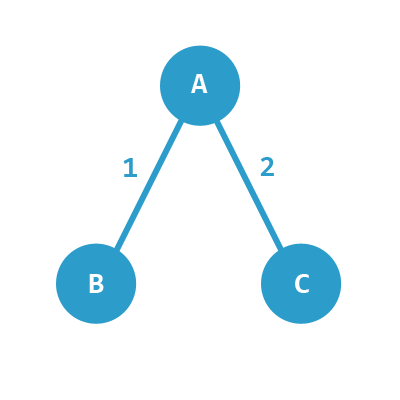

For a graph like this, with elements A, B and C, the connections are:

A & B are connected with weight 1.

A & C are connected with weight 2.

C & B is not connected.

The Adjency Matrix would look like this:

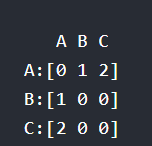

In [30]:
"""
Connected Components
Find all of the connected components with the connected_components() method.
"""

arr = np.array([
  [0, 1, 2],
  [1, 0, 0],
  [2, 0, 0]
])

new_arr = csr_matrix(arr)
print(csgraph.connected_components(new_arr))

(1, array([0, 0, 0], dtype=int32))


###Working with Spatial Data

Spatial data refers to data that is represented in a geometric space.

E.g. points on a coordinate system.

We deal with spatial data problems on many tasks.

E.g. finding if a point is inside a boundary or not.

SciPy provides us with the module scipy.spatial, which has functions for working with spatial data.

**Triangulation**

A Triangulation of a polygon is to divide the polygon into multiple triangles with which we can compute an area of the polygon.

A Triangulation with points means creating surface composed triangles in which all of the given points are on at least one vertex of any triangle in the surface.

One method to generate these triangulations through points is the `Delaunay()`
Triangulation.

Delaunay triangulation takes a set of points, connects them into optimal triangles, and by summing the area of each triangle we can calculate the total area of any complex shape.

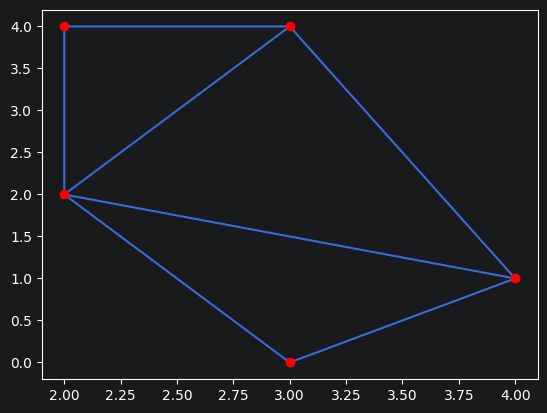

In [41]:
from scipy.spatial import Delaunay
points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1]
])

plt.triplot(points[:, 0], points[:, 1])
plt.scatter(points[:, 0], points[:, 1], color='r')
plt.show()



In [42]:
# simplices gives us the indices of the 3 points that form each triangle
# So triangle [3, 2, 4] means it's formed by points[3], points[2], points[4] — and from those coordinates you can calculate the area using the triangle area formula.
points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1]
])
simplices = Delaunay(points).simplices
print(simplices)

[[3 2 4]
 [3 1 0]
 [1 3 4]]


In [39]:
# now we calculate the area of one triangle
tri = points[simplices[0]]  # get coordinates of first triangle
x1, y1 = tri[0]
x2, y2 = tri[1]
x3, y3 = tri[2]

area = 0.5 * abs(x1*(y2-y3) + x2*(y3-y1) + x3*(y1-y2))
print("the area of first triangle is ", area)

the area of first tri angel is  1.5


In [51]:
# or we can use loop to show the area of all triangles and sum them to show the overall area of the shape
points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1]
])
simplices = Delaunay(points).simplices
total_area = 0
for tri_indices in simplices:
    tri = points[tri_indices]
    x1, y1 = tri[0]
    x2, y2 = tri[1]
    x3, y3 = tri[2]
    area = 0.5 * abs(x1*(y2-y3) + x2*(y3-y1) + x3*(y1-y2))
    print("the area of each triangle is ", area)
    total_area += area
print("the total area of the shape is ", total_area)


the area of each triangle is  1.5
the area of each triangle is  1.0
the area of each triangle is  2.5
the total area of the shape is  5.0


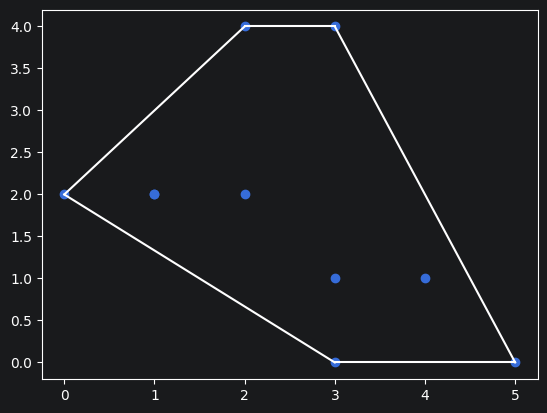

In [58]:
"""
Convex Hull is the smallest convex shape that contains all your points — like stretching a rubber band around all the points and letting it snap tight.

It finds the outer boundary points — the points on the edge of the shape, ignoring interior points.
"""
from scipy.spatial import ConvexHull
points = np.array([
  [2, 4],
  [3, 4],
  [3, 0],
  [2, 2],
  [4, 1],
  [1, 2],
  [5, 0],
  [3, 1],
  [1, 2],
  [0, 2]
])

plt.scatter(points[:, 0], points[:, 1])

# finds the outer boundary of all points.
hull = ConvexHull(points)
# gives you the indices of the edge lines (pairs of points) that form the boundary, similar to how Delaunay's simplices gave triangle indices but here each row is just 2 points (a line) not 3.
hull_points = hull.simplices

for simplex in hull_points:
    plt.plot(points[simplex,0], points[simplex,1], 'w')
plt.show()



### KDTrees

KDTrees are a datastructure optimized for nearest neighbor queries.

E.g. in a set of points using KDTrees we can efficiently ask which points are nearest to a certain given point.

The KDTree() method returns a KDTree object.

The query() method returns the distance to the nearest neighbor and the location of the neighbors.

In [64]:
"""
KDTree builds a tree structure from a set of points for fast searching.
E.g. KDTree([(1, -1), (2, 3), (-2, 3), (2, -3)]) builds the tree.

query() finds the nearest point to a given point.
E.g. kdtree.query((1, 1)) finds the nearest point to (1, 1).

Returns the Euclidean distance and index of the nearest point.
E.g. (2.0, 0) means distance=2.0, nearest point is at index 0 → (1, -1).

Faster than manually calculating distance to every point for large datasets.
"""

from scipy.spatial import KDTree

points = [(1, -1), (2, 3), (-2, 3), (2, -3)]

kdtree = KDTree(points)

distance, index = kdtree.query((1, 1))
print((distance, int(index)))


(2.0, 0)


### Distance Matrix
There are many Distance Metrics used to find various types of distances between two points in data science, Euclidean distsance, cosine distsance etc.

The distance between two vectors may not only be the length of straight line between them, it can also be the angle between them from origin, or number of unit steps required etc.
Using the Euclidean distance formula:

Many of the Machine Learning algorithm's performance depends greatly on distance metrices. E.g. "K Nearest Neighbors", or "K Means" etc.

The Euclidean distance between two points is calculated as $$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$


Manhattan distance is the sum of the absolute differences of the coordinates — like navigating a city grid where you can only move horizontally or vertically, not diagonally.

$$d = |x_2 - x_1| + |y_2 - y_1|$$

Cosine distance measures the angle between two vectors, not the straight-line distance.

$$D_c(\mathbf{A}, \mathbf{B}) = 1 - \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|} = 1 - \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

Cosine distance is defined as $D_c = 1 - \cos(\theta)$, where $\theta$ is the angle between the two vectors.

Hamming distance counts the number of positions where two sequences differ.

$$d_H(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} [x_i \neq y_i]$$

In [67]:
"""
Euclidean Distance
Find the euclidean distance between given points.
"""
from scipy.spatial.distance import euclidean

p1 = (1, 0)
p2 = (10, 2)

res = euclidean(p1, p2)

print(res)

9.219544457292887


In [68]:
"""
Cityblock Distance (Manhattan Distance)
Is the distance computed using 4 degrees of movement.

E.g. we can only move: up, down, right, or left, not diagonally.
"""

from scipy.spatial.distance import cityblock

p1 = (1, 0)
p2 = (10, 2)

res = cityblock(p1, p2)

print(res)

11


In [69]:
"""
Cosine Distance
Is the value of cosine angle between the two points A and B.
"""
from scipy.spatial.distance import cosine

p1 = (1, 0)
p2 = (10, 2)

res = cosine(p1, p2)

print(res)

0.019419324309079777


In [70]:
"""
Hamming Distance
Is the proportion of bits where two bits are different.

It's a way to measure distance for binary sequences.
"""
from scipy.spatial.distance import hamming

p1 = (True, False, True)
p2 = (False, True, True)

res = hamming(p1, p2)

print(res)


0.6666666666666666


### Working With Matlab Arrays
We know that NumPy provides us with methods to persist the data in readable formats for Python. But SciPy provides us with interoperability with Matlab as well.

SciPy provides us with the module scipy.io, which has functions for working with Matlab arrays.

In [72]:
"""
Exporting Data in Matlab Format
The savemat() function allows us to export data in Matlab format.

The method takes the following parameters:

filename - the file name for saving data.
mdict - a dictionary containing the data.
do_compression - a boolean value that specifies whether to compress the result or not. Default False.
"""

from scipy import io
import numpy as np

arr = np.arange(10)

io.savemat('arr.mat', {"vec": arr})

In [73]:
"""
Import Data from Matlab Format
The loadmat() function allows us to import data from a Matlab file.

The function takes one required parameter:

filename - the file name of the saved data.

It will return a structured array whose keys are the variable names, and the corresponding values are the variable values.
"""
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9,])

# Export:
io.savemat('arr.mat', {"vec": arr})

# Import:
mydata = io.loadmat('arr.mat')

print(mydata)

{'__header__': b'MATLAB 5.0 MAT-file Platform: nt, Created on: Fri Jun  5 20:40:09 2026', '__version__': '1.0', '__globals__': [], 'vec': array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])}


### What is Interpolation?
Interpolation is a method for generating points between given points.

For example: for points 1 and 2, we may interpolate and find points 1.33 and 1.66.

Interpolation has many usage, in Machine Learning we often deal with missing data in a dataset, interpolation is often used to substitute those values.

This method of filling values is called imputation.

Apart from imputation, interpolation is often used where we need to smooth the discrete points in a dataset.

SciPy provides us with a module called `scipy.interpolate` which has many functions to deal with interpolation



In [ ]:
"""
1D Interpolation
The function interp1d() is used to interpolate a distribution with 1 variable.

It takes x and y points and returns a callable function that can be called with new x and returns corresponding y.
"""

from scipy.interpolate import interp1d
xs = np.arange(10)
ys = 2*xs + 1

pr  